# Signal-Final: Final End-to-End Signal Notebook

Notebook ini adalah versi final yang dipakai untuk belajar alur kerja refinement terbaru secara utuh.

Fokusnya bukan lagi eksperimen, tetapi satu pipeline final yang rapi:
- data 5-hari yang sudah dibersihkan
- target binary actionable signal
- feature engineering final
- Logistic Regression final
- evaluasi visual yang mudah dibaca

Tujuan notebook ini adalah membuat kita bisa melihat dengan mata sendiri apakah hasil akhirnya memang masuk akal, bukan hanya bagus di angka metrik.

## How to Read This Notebook

Sebelum melihat hasil model, kita perlu paham dulu dua ide paling dasar:

- **Probability**: angka 0 sampai 1 yang menunjukkan seberapa yakin model bahwa sebuah baris termasuk kelas `action`.
- **Threshold**: batas yang dipakai untuk mengubah probability menjadi keputusan.

Contoh sederhana:
- probability `0.20` berarti model cenderung bilang `no-action`
- probability `0.65` berarti model cenderung bilang `action`
- kalau threshold `0.50`, maka `0.65` dianggap `action`
- kalau threshold `0.70`, maka `0.65` belum cukup kuat

Jadi:
- probability = tingkat keyakinan model
- threshold = garis keputusan

Bagian ini sengaja ditaruh di awal supaya output berikutnya lebih mudah dibaca.

,probability,if_threshold_0.50,if_threshold_0.70
0,0.20,no-action,no-action
1,0.48,no-action,no-action
2,0.65,action,no-action
3,0.82,action,action


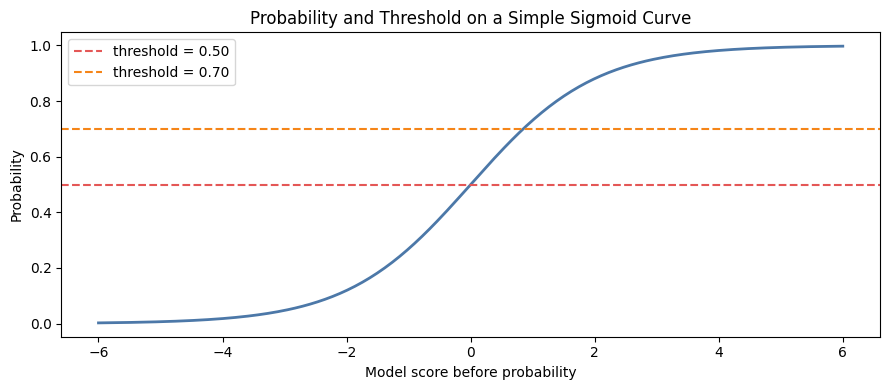

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

toy = pd.DataFrame([
    {"probability": 0.20, "if_threshold_0.50": "no-action", "if_threshold_0.70": "no-action"},
    {"probability": 0.48, "if_threshold_0.50": "no-action", "if_threshold_0.70": "no-action"},
    {"probability": 0.65, "if_threshold_0.50": "action", "if_threshold_0.70": "no-action"},
    {"probability": 0.82, "if_threshold_0.50": "action", "if_threshold_0.70": "action"},
])
display(toy)

xs = np.linspace(-6, 6, 300)
sigmoid = 1 / (1 + np.exp(-xs))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(xs, sigmoid, color="#4C78A8", linewidth=2)
ax.axhline(0.50, color="#E45756", linestyle="--", label="threshold = 0.50")
ax.axhline(0.70, color="#F58518", linestyle="--", label="threshold = 0.70")
ax.set_title("Probability and Threshold on a Simple Sigmoid Curve")
ax.set_xlabel("Model score before probability")
ax.set_ylabel("Probability")
ax.legend()
plt.tight_layout()
plt.show()

## Quick Glossary

- **Actionable signal**: sinyal yang menandakan ada pergerakan yang cukup berarti untuk diperhatikan.
- **No-action**: sinyal yang tidak cukup kuat untuk memicu perhatian.
- **Threshold**: batas probabilitas untuk mengubah output model menjadi keputusan.
- **Balanced accuracy**: rata-rata performa model pada kelas positif dan negatif.
- **Precision**: seberapa sering sinyal positif yang keluar memang benar.
- **Recall**: seberapa banyak kejadian positif yang berhasil ditangkap model.
- **F1-score**: ringkasan dari precision dan recall.
- **AUC**: ukuran kemampuan model membedakan kelas positif dan negatif.
- **Feature engineering**: membuat fitur baru dari data yang sudah ada agar model lebih mudah belajar.
- **Coefficient**: bobot fitur pada logistic regression; tanda positif/negatif menunjukkan arah pengaruh dalam model.

## How to Read the Metrics

Metrik yang sering muncul di notebook ini berarti:

- **Accuracy**: seberapa sering model benar secara total.
- **Balanced accuracy**: accuracy yang memperlakukan kelas `action` dan `no-action` lebih seimbang.
- **Precision**: dari semua sinyal `action` yang keluar, berapa banyak yang benar.
- **Recall**: dari semua kejadian `action` yang memang ada, berapa banyak yang berhasil ditangkap.
- **F1**: gabungan precision dan recall.
- **AUC**: kemampuan model membedakan `action` vs `no-action` terlepas dari threshold.

Intuisi sederhananya:
- precision tinggi = sinyal lebih bersih
- recall tinggi = sinyal lebih lengkap
- balanced accuracy tinggi = model lebih adil ke dua kelas

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 220)


def find_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Project root not found")


ROOT = find_root(Path.cwd())
PROCESSED = ROOT / "data" / "processed"

v2 = pd.read_csv(PROCESSED / "five_day_signal_expanded_v2.csv", parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)
v3 = pd.read_csv(PROCESSED / "five_day_signal_expanded_v3.csv", parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)

print("v2 shape:", v2.shape)
print("v3 shape:", v3.shape)

v2 shape: (637, 152)
v3 shape: (637, 202)


## What This Notebook Uses

Notebook ini menggunakan hasil refinement terbaru sebagai satu pipeline final:

- **Dataset final**: `five_day_signal_expanded_v3`
- **Target final**: binary actionable signal
- **Model final**: Logistic Regression
- **Feature mode final**: engineered features without `current_block`

Jadi notebook ini bukan daftar eksperimen, melainkan ringkasan final yang masih menjelaskan proses pembentukannya.

In [3]:
FEATURE_EXCLUDE = {
    "block_id", "ds", "block_start_ds", "block_end_ds", "target_ds",
    "target_next_close", "target_next_change", "target_next_return", "target_next_log_return",
    "target_next_direction", "y", "signal_binary", "current_block_ohlc_dirty"
}
QC_PREFIXES = ("target_ohlc_has_placeholder_one_",)

ENGINEERED_EXTRA_COLS = [c for c in v3.columns if c not in v2.columns and c not in FEATURE_EXCLUDE]


def train_tau(frame: pd.DataFrame, train_frac: float = 0.7) -> float:
    split = int(len(frame) * train_frac)
    return float(frame["y"].iloc[:split].abs().median())


def build_binary_signal(frame: pd.DataFrame, tau: float) -> pd.Series:
    return (frame["y"].abs() > tau).astype(int)


def select_features(frame: pd.DataFrame, include_engineered: bool) -> pd.DataFrame:
    X = frame[[c for c in frame.columns if c not in FEATURE_EXCLUDE]].select_dtypes(include=[np.number]).copy()
    X = X[[c for c in X.columns if not c.startswith("current_block_") and not c.startswith("block_end_")]]
    X = X[[c for c in X.columns if not c.startswith(QC_PREFIXES)]]
    if not include_engineered:
        X = X[[c for c in X.columns if c not in ENGINEERED_EXTRA_COLS]]
    return X


def make_model(penalty="l1", solver="liblinear", C=1.0, class_weight=None):
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=5000,
            penalty=penalty,
            solver=solver,
            C=C,
            class_weight=class_weight,
        )),
    ])


def evaluate_frame(frame: pd.DataFrame, include_engineered: bool, params: dict, n_splits: int = 5):
    work = frame.copy()
    tau = train_tau(work)
    work["signal_binary"] = build_binary_signal(work, tau)
    X = select_features(work, include_engineered=include_engineered)
    y = work["signal_binary"].copy()

    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_rows = []
    last = None
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        model = make_model(**params)
        model.fit(X_train, y_train)
        prob = model.predict_proba(X_test)[:, 1]
        pred = (prob >= 0.5).astype(int)

        fold_rows.append({
            "fold": fold,
            "acc": accuracy_score(y_test, pred),
            "bal_acc": balanced_accuracy_score(y_test, pred),
            "f1": f1_score(y_test, pred, zero_division=0),
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred, zero_division=0),
            "auc": roc_auc_score(y_test, prob),
            "flag_rate": float(pred.mean()),
        })

        last = {
            "X_test": X_test,
            "y_test": y_test,
            "prob": prob,
            "pred": pred,
            "model": model,
            "tau": tau,
            "features": X.columns,
        }

    return tau, pd.DataFrame(fold_rows), last

## Final Dataset Snapshot

Kita mulai dari gambaran singkat dataset final agar jelas apa yang dipakai model.

Yang penting di sini:
- jumlah baris
- rentang tanggal
- keseimbangan kelas
- threshold signal yang dipakai

,rows,columns,start_date,end_date,tau,actionable_rate,no_action_rate
0,637,202,2013-07-08,2026-03-05,0.0166,0.5181,0.4819


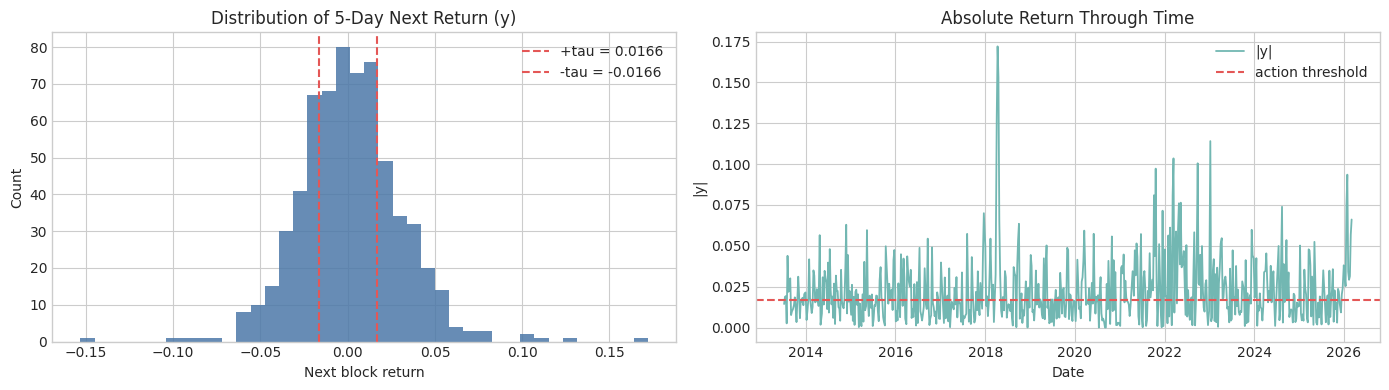

Actionable signal means the absolute 5-day return is above the threshold.


In [4]:
tau_final = train_tau(v3)
v3_work = v3.copy()
v3_work["signal_binary"] = build_binary_signal(v3_work, tau_final)

snapshot = pd.DataFrame({
    "rows": [len(v3_work)],
    "columns": [len(v3_work.columns)],
    "start_date": [v3_work["ds"].min().date().isoformat()],
    "end_date": [v3_work["ds"].max().date().isoformat()],
    "tau": [tau_final],
    "actionable_rate": [v3_work["signal_binary"].mean()],
    "no_action_rate": [1 - v3_work["signal_binary"].mean()],
})
display(snapshot.round(4))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].hist(v3_work["y"], bins=40, color="#4C78A8", alpha=0.85)
ax[0].axvline(tau_final, color="#E45756", linestyle="--", label=f"+tau = {tau_final:.4f}")
ax[0].axvline(-tau_final, color="#E45756", linestyle="--", label=f"-tau = {-tau_final:.4f}")
ax[0].set_title("Distribution of 5-Day Next Return (y)")
ax[0].set_xlabel("Next block return")
ax[0].set_ylabel("Count")
ax[0].legend()

ax[1].plot(v3_work["ds"], v3_work["y"].abs(), color="#72B7B2", linewidth=1.3, label="|y|")
ax[1].axhline(tau_final, color="#E45756", linestyle="--", label="action threshold")
ax[1].set_title("Absolute Return Through Time")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("|y|")
ax[1].legend()
plt.tight_layout()
plt.show()

print("Actionable signal means the absolute 5-day return is above the threshold.")

## Why These Features Exist

Feature engineering di final notebook ini dibuat untuk membantu model membaca bentuk sinyal yang lebih kaya.

Secara sederhana, fitur dibagi menjadi:
- **blok harga**: seperti body, wick, dan posisi close
- **history target**: lag, rolling mean, rolling std, momentum
- **market spreads**: selisih antar pasar dan rasio sederhana
- **freshness**: seberapa segar sinyal exogenous yang dipakai

Ini bukan fitur acak; semuanya dirancang agar model melihat struktur pasar, bukan cuma angka mentah.

,group,feature_count,examples
0,block_shape,10,"block_body_to_range, block_close_location, blo..."
1,target_history,18,"y_lag1, y_lag2, y_lag3, y_lag4..."
2,market_spreads,13,"spread_shfe_brent_last, spread_shfe_lme_last, ..."
3,freshness,8,"freshness_brent, freshness_shfe, freshness_opt..."


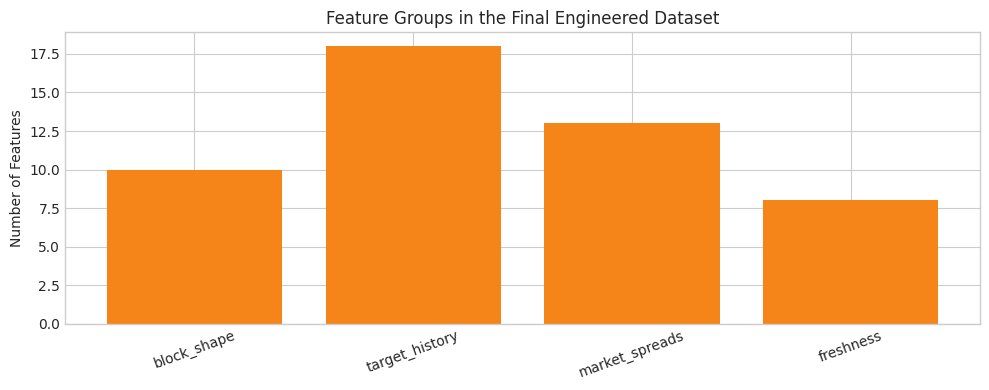

In [5]:
feature_groups = {
    "block_shape": [
        "block_body_to_range", "block_close_location", "block_upper_wick", "block_lower_wick",
        "block_wick_balance", "block_efficiency", "block_up_rate", "block_vol_adj_body",
        "block_range_to_open", "block_close_to_open",
    ],
    "target_history": [
        "y_lag1", "y_lag2", "y_lag3", "y_lag4", "y_lag5",
        "y_roll_mean_3", "y_roll_std_3", "y_abs_roll_mean_3", "y_trend_strength_3",
        "y_roll_mean_5", "y_roll_std_5", "y_abs_roll_mean_5", "y_trend_strength_5",
        "y_momentum_3", "y_momentum_5", "y_abs_lag1", "y_abs_lag3", "y_abs_lag5",
    ],
    "market_spreads": [
        "spread_shfe_brent_last", "spread_shfe_lme_last", "spread_lme_brent_last",
        "spread_shfe_brent_change", "spread_shfe_lme_change", "spread_lme_brent_change",
        "opt_call_minus_official_share_last", "opt_call_minus_official_share_change",
        "opt_activity_strength_last", "opt_activity_strength_change",
        "stock_to_shfe_price_last", "stock_to_lme_price_last", "fx_brent_product_last",
    ],
    "freshness": [
        "freshness_brent", "freshness_shfe", "freshness_option", "freshness_mean",
        "freshness_min", "staleness_gap_shfe_brent", "staleness_gap_option_shfe", "staleness_max",
    ],
}

group_rows = []
for group_name, cols in feature_groups.items():
    group_rows.append({
        "group": group_name,
        "feature_count": len(cols),
        "examples": ", ".join(cols[:4]) + ("..." if len(cols) > 4 else ""),
    })
display(pd.DataFrame(group_rows))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([r["group"] for r in group_rows], [r["feature_count"] for r in group_rows], color="#F58518")
ax.set_title("Feature Groups in the Final Engineered Dataset")
ax.set_ylabel("Number of Features")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Final Model and Evaluation Design

Model final yang dipilih adalah **Logistic Regression**.

Sederhananya:
- Logistic Regression memetakan fitur ke probabilitas
- probabilitas itu lalu diubah menjadi keputusan `action` atau `ignore`
- threshold yang dipakai menentukan seberapa sering model memberi sinyal

Evaluasi dilakukan dengan **TimeSeriesSplit**, yaitu pembagian data yang menjaga urutan waktu.
Ini penting karena kita ingin evaluasi yang realistis, bukan evaluasi acak yang membocorkan masa depan.

,dataset,acc,bal_acc,f1,precision,recall,auc,flag_rate
0,baseline_v2,0.5113,0.5241,0.5013,0.5602,0.4998,0.5333,0.4830
1,final_v3,0.5358,0.5423,0.5342,0.5586,0.5448,0.5428,0.5038


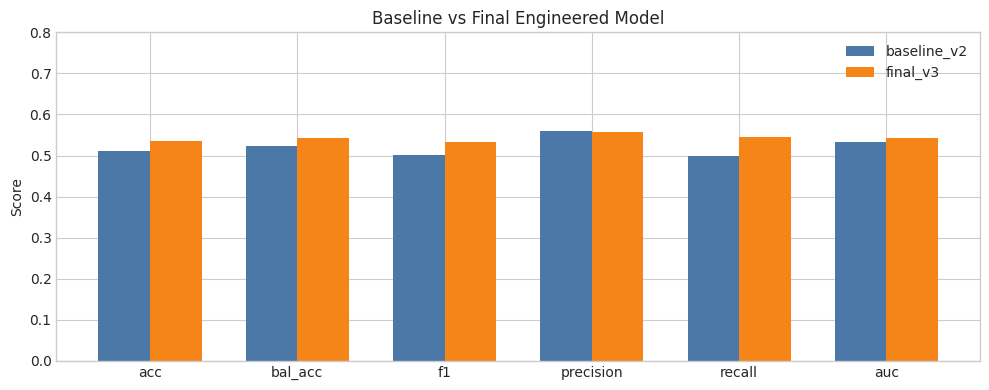

In [6]:
baseline_params = {"penalty": "l2", "solver": "lbfgs", "C": 3.0, "class_weight": None}
final_params = {"penalty": "l1", "solver": "liblinear", "C": 1.0, "class_weight": None}

v2_tau, v2_fold_df, v2_last = evaluate_frame(v2, include_engineered=False, params=baseline_params)
v3_tau, v3_fold_df, v3_last = evaluate_frame(v3, include_engineered=True, params=final_params)

comparison = pd.DataFrame([
    {"dataset": "baseline_v2", **v2_fold_df[["acc", "bal_acc", "f1", "precision", "recall", "auc", "flag_rate"]].mean().to_dict()},
    {"dataset": "final_v3", **v3_fold_df[["acc", "bal_acc", "f1", "precision", "recall", "auc", "flag_rate"]].mean().to_dict()},
]).round(4)
display(comparison)

fig, ax = plt.subplots(figsize=(10, 4))
metrics = ["acc", "bal_acc", "f1", "precision", "recall", "auc"]
x = np.arange(len(metrics))
width = 0.35
ax.bar(x - width/2, [v2_fold_df[m].mean() for m in metrics], width, label="baseline_v2", color="#4C78A8")
ax.bar(x + width/2, [v3_fold_df[m].mean() for m in metrics], width, label="final_v3", color="#F58518")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 0.8)
ax.set_title("Baseline vs Final Engineered Model")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

## Threshold Trade-off

Threshold adalah salah satu bagian paling penting dalam penggunaan model.

- threshold rendah: model lebih sering bilang `action`, coverage tinggi, tapi false alarm lebih banyak
- threshold tinggi: model lebih konservatif, sinyal lebih jarang, tapi biasanya lebih bersih

Di bagian ini kita lihat trade-off tersebut pada final model.

,acc,bal_acc,f1,precision,recall,flag_rate
thr,,,,,,
0.45,0.5283,0.5311,0.5598,0.5473,0.6010,0.5717
0.50,0.5358,0.5423,0.5342,0.5586,0.5448,0.5038
0.55,0.5321,0.5410,0.5178,0.5614,0.5136,0.4736
0.60,0.5245,0.5375,0.4807,0.5629,0.4540,0.4170
0.65,0.5113,0.5285,0.4175,0.5588,0.3676,0.3396
0.70,0.5075,0.5283,0.3611,0.5917,0.2931,0.2679


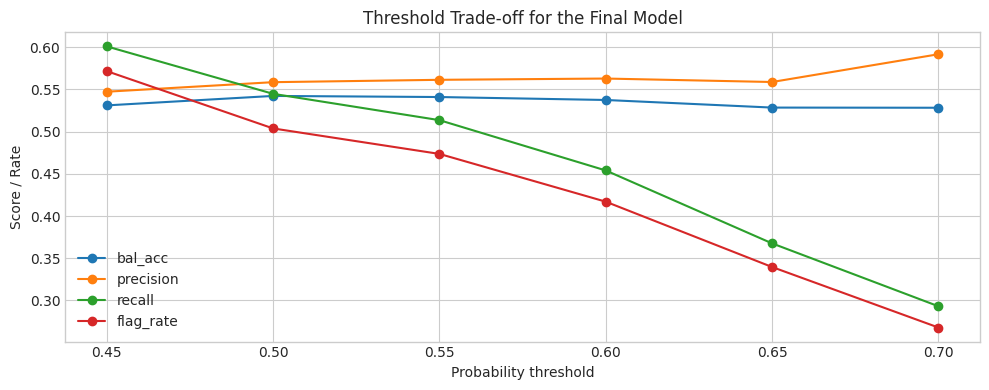

In [7]:
thresholds = [0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
threshold_rows = []
last_fold_artifacts = None

X_v3 = select_features(v3.assign(signal_binary=build_binary_signal(v3, v3_tau)), include_engineered=True)
y_v3 = build_binary_signal(v3, v3_tau)

tscv = TimeSeriesSplit(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_v3), start=1):
    X_train, X_test = X_v3.iloc[train_idx], X_v3.iloc[test_idx]
    y_train, y_test = y_v3.iloc[train_idx], y_v3.iloc[test_idx]
    model = make_model(**final_params)
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]

    if fold == 5:
        last_fold_artifacts = (y_test, prob, X_test, model, test_idx)

    for thr in thresholds:
        pred = (prob >= thr).astype(int)
        threshold_rows.append({
            "fold": fold,
            "thr": thr,
            "acc": accuracy_score(y_test, pred),
            "bal_acc": balanced_accuracy_score(y_test, pred),
            "f1": f1_score(y_test, pred, zero_division=0),
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred, zero_division=0),
            "flag_rate": float(pred.mean()),
        })

threshold_df = pd.DataFrame(threshold_rows)
threshold_summary = threshold_df.groupby("thr")[["acc", "bal_acc", "f1", "precision", "recall", "flag_rate"]].mean().round(4)
display(threshold_summary)

fig, ax = plt.subplots(figsize=(10, 4))
threshold_summary[["bal_acc", "precision", "recall", "flag_rate"]].plot(ax=ax, marker="o")
ax.set_title("Threshold Trade-off for the Final Model")
ax.set_xlabel("Probability threshold")
ax.set_ylabel("Score / Rate")
plt.tight_layout()
plt.show()

## Final Fold: Actual vs Predicted

Ini visual paling penting untuk membaca apakah model terasa masuk akal.

Yang ingin kita lihat:
- apakah probabilitas model naik saat memang ada pergerakan besar
- apakah garis threshold memisahkan sinyal yang lemah dan kuat
- apakah model sering salah di area yang memang sulit

Best threshold: 0.50
Confusion matrix:
[[16 34]
 [ 6 50]]

Classification report:
              precision    recall  f1-score   support

           0     0.7273    0.3200    0.4444        50
           1     0.5952    0.8929    0.7143        56

    accuracy                         0.6226       106
   macro avg     0.6613    0.6064    0.5794       106
weighted avg     0.6575    0.6226    0.5870       106



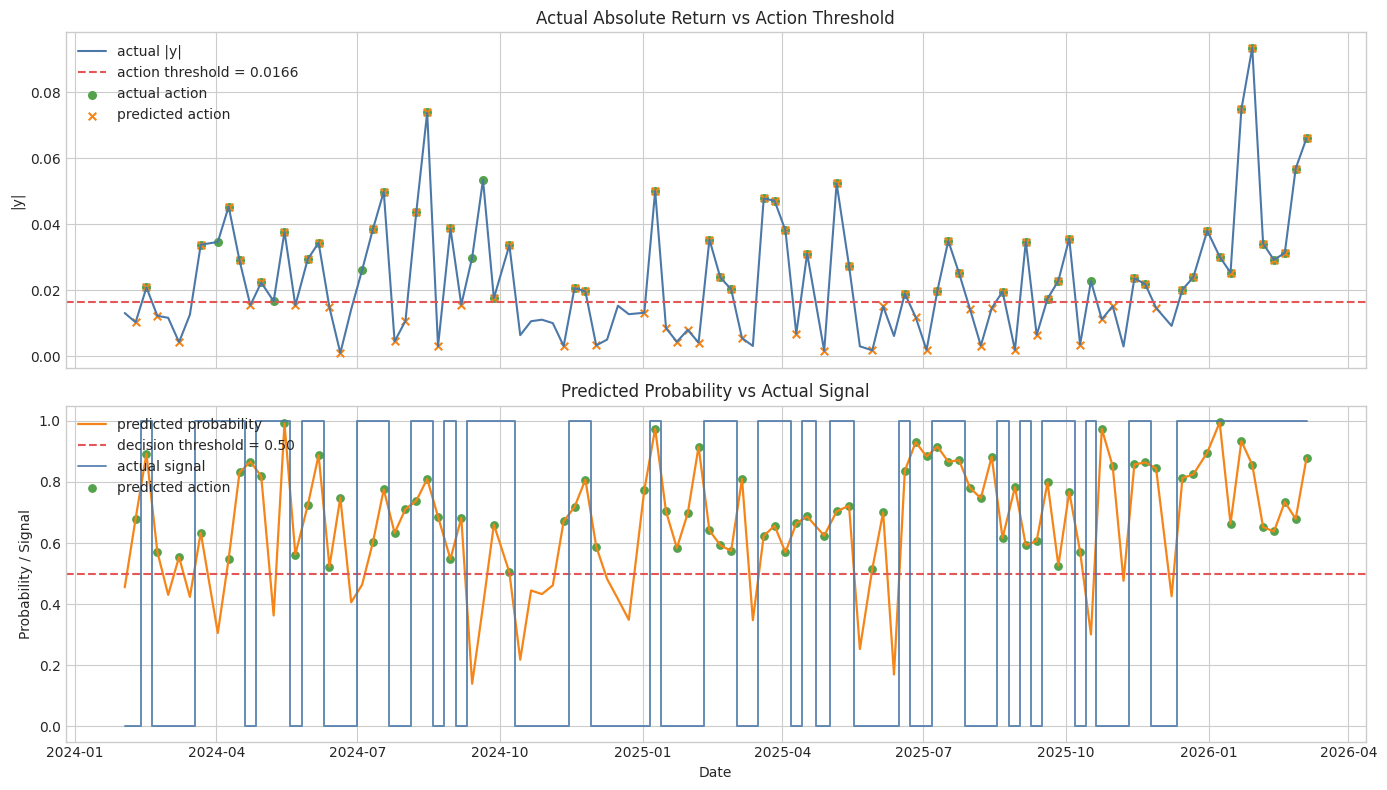

In [8]:
best_thr = float(threshold_summary["bal_acc"].idxmax())
y_test, prob, X_test, model, test_idx = last_fold_artifacts
pred = (prob >= best_thr).astype(int)
fold_dates = v3.loc[test_idx, "ds"].reset_index(drop=True)
fold_abs_y = v3.loc[test_idx, "y"].abs().reset_index(drop=True)
fold_signal = y_test.reset_index(drop=True)

print(f"Best threshold: {best_thr:.2f}")
print("Confusion matrix:")
print(confusion_matrix(y_test, pred))
print("\nClassification report:")
print(classification_report(y_test, pred, digits=4, zero_division=0))

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(fold_dates, fold_abs_y, color="#4C78A8", linewidth=1.5, label="actual |y|")
ax[0].axhline(v3_tau, color="#E45756", linestyle="--", label=f"action threshold = {v3_tau:.4f}")
ax[0].scatter(fold_dates[fold_signal == 1], fold_abs_y[fold_signal == 1], color="#54A24B", s=30, label="actual action")
ax[0].scatter(fold_dates[pred == 1], fold_abs_y[pred == 1], color="#F58518", s=30, marker="x", label="predicted action")
ax[0].set_title("Actual Absolute Return vs Action Threshold")
ax[0].set_ylabel("|y|")
ax[0].legend(loc="upper left")

ax[1].plot(fold_dates, prob, color="#F58518", linewidth=1.6, label="predicted probability")
ax[1].axhline(best_thr, color="#E45756", linestyle="--", label=f"decision threshold = {best_thr:.2f}")
ax[1].step(fold_dates, fold_signal, where="mid", color="#4C78A8", linewidth=1.4, alpha=0.85, label="actual signal")
ax[1].scatter(fold_dates[pred == 1], prob[pred == 1], color="#54A24B", s=28, label="predicted action")
ax[1].set_title("Predicted Probability vs Actual Signal")
ax[1].set_ylabel("Probability / Signal")
ax[1].set_xlabel("Date")
ax[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

## ROC and Precision-Recall Curves

Dua visual ini membantu kita melihat performa model dari sudut yang berbeda:
- **ROC curve**: seberapa baik model memisahkan kelas
- **Precision-Recall curve**: seberapa baik model menjaga sinyal positif tetap bersih

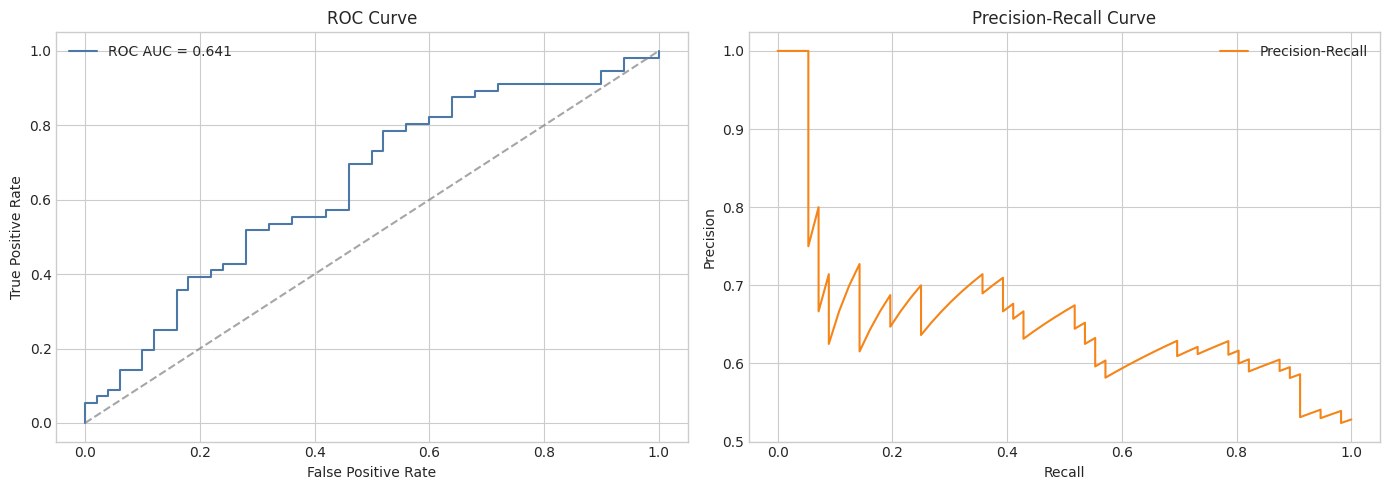

In [9]:
y_prob = prob
fpr, tpr, _ = roc_curve(y_test, y_prob)
prec, rec, _ = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(fpr, tpr, color="#4C78A8", label=f"ROC AUC = {roc_auc_score(y_test, y_prob):.3f}")
ax[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.7)
ax[0].set_title("ROC Curve")
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].legend()

ax[1].plot(rec, prec, color="#F58518", label="Precision-Recall")
ax[1].set_title("Precision-Recall Curve")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].legend()

plt.tight_layout()
plt.show()

## Feature Coefficients

Karena model final kita adalah Logistic Regression, koefisiennya bisa dibaca sebagai sinyal relatif:
- koefisien positif: fitur mendorong model ke arah `action`
- koefisien negatif: fitur mendorong model ke arah `no-action`

Ini bukan sebab-akibat. Ini hanya cara model memberi bobot pada fitur.

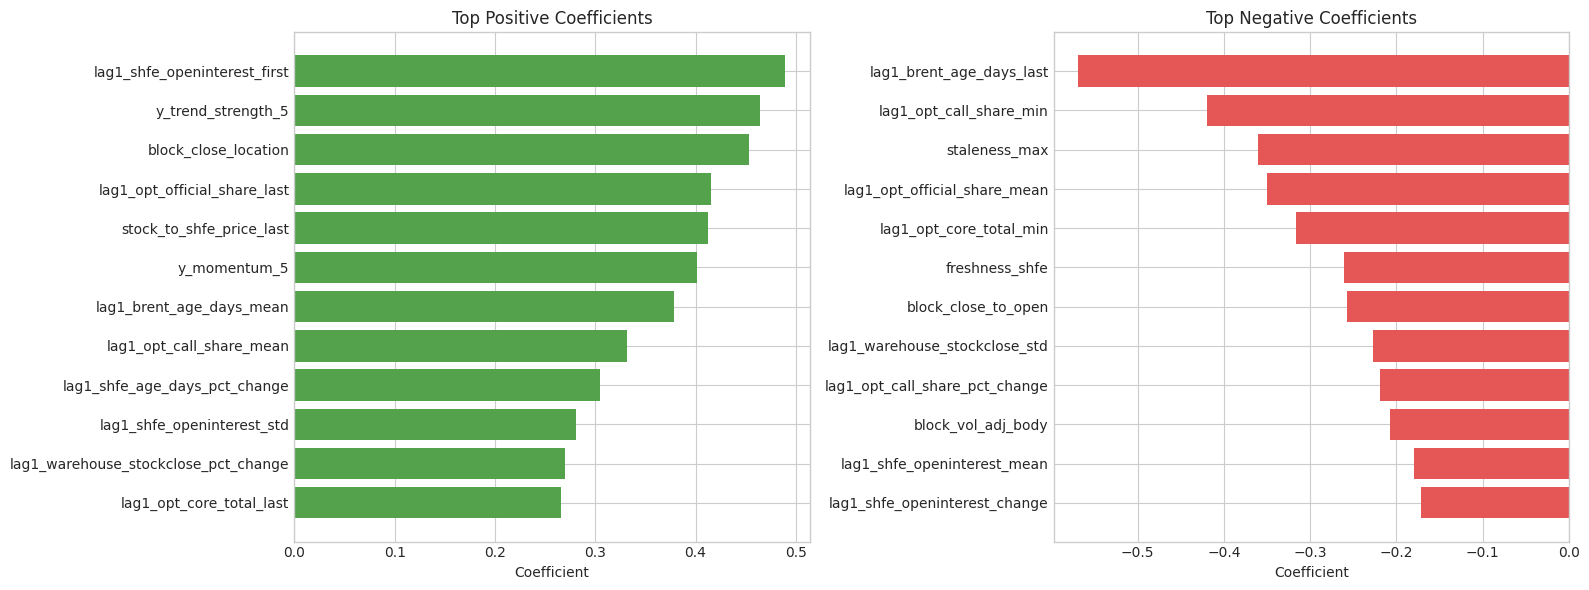

,feature,coef,abs_coef
49,lag1_shfe_openinterest_first,0.4895,0.4895
137,y_trend_strength_5,0.4646,0.4646
116,block_close_location,0.4538,0.4538
82,lag1_opt_official_share_last,0.4154,0.4154
153,stock_to_shfe_price_last,0.4123,0.4123
139,y_momentum_5,0.4014,0.4014
35,lag1_brent_age_days_mean,0.3789,0.3789
91,lag1_opt_call_share_mean,0.3318,0.3318
104,lag1_shfe_age_days_pct_change,0.3051,0.3051
52,lag1_shfe_openinterest_std,0.2805,0.2805


,feature,coef,abs_coef
34,lag1_brent_age_days_last,-0.5690,0.5690
93,lag1_opt_call_share_min,-0.4197,0.4197
163,staleness_max,-0.3610,0.3610
83,lag1_opt_official_share_mean,-0.3498,0.3498
77,lag1_opt_core_total_min,-0.3160,0.3160
157,freshness_shfe,-0.2609,0.2609
124,block_close_to_open,-0.2572,0.2572
4,lag1_warehouse_stockclose_std,-0.2273,0.2273
96,lag1_opt_call_share_pct_change,-0.2188,0.2188
122,block_vol_adj_body,-0.2078,0.2078


In [10]:
coef = pd.DataFrame({
    "feature": X_test.columns,
    "coef": model.named_steps["model"].coef_[0],
})
coef["abs_coef"] = coef["coef"].abs()

top_pos = coef.sort_values("coef", ascending=False).head(12)
top_neg = coef.sort_values("coef", ascending=True).head(12)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].barh(top_pos["feature"][::-1], top_pos["coef"][::-1], color="#54A24B")
ax[0].set_title("Top Positive Coefficients")
ax[0].set_xlabel("Coefficient")

ax[1].barh(top_neg["feature"][::-1], top_neg["coef"][::-1], color="#E45756")
ax[1].set_title("Top Negative Coefficients")
ax[1].set_xlabel("Coefficient")

plt.tight_layout()
plt.show()

display(top_pos.round(4))
display(top_neg.round(4))

## Final Operating Rule

Dari hasil evaluasi, aturan pakai yang paling masuk akal adalah:

- **Ignore**: probabilitas di bawah `0.50`
- **Watch**: probabilitas sekitar `0.50` sampai `0.65`
- **Act**: probabilitas di atas `0.65`

Ini membuat model lebih mudah dipakai sebagai alat bantu keputusan, bukan sebagai penentu tunggal.

In [11]:
decision_table = pd.DataFrame([
    {"probability_range": "< 0.50", "action": "ignore", "meaning": "sinyal terlalu lemah"},
    {"probability_range": "0.50 - 0.65", "action": "watch", "meaning": "layak dipantau"},
    {"probability_range": "> 0.65", "action": "act", "meaning": "sinyal cukup kuat"},
])
display(decision_table)

,probability_range,action,meaning
0,< 0.50,ignore,sinyal terlalu lemah
1,0.50 - 0.65,watch,layak dipantau
2,> 0.65,act,sinyal cukup kuat


## Closing Summary

Notebook ini menunjukkan satu alur final yang utuh:
- data 5-hari yang bersih
- target actionable signal
- feature engineering yang lebih kaya
- Logistic Regression final
- visual actual vs predicted yang mudah dibaca

Hasilnya tidak sempurna, tetapi cukup kuat untuk disebut sebagai baseline final yang paling sehat saat ini.